In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('data/Medical-Insurance.csv')
df.columns = ['age', 'gender', 'bmi', 'no of children', 'smoker', 'region', 'charges']
print(df.head())


  age  gender     bmi  no of children smoker  region      charges
0  18       2  33.770               1      0       4   1725.55230
1  28       2  33.000               3      0       4   4449.46200
2  33       2  22.705               0      0       1  21984.47061
3  32       2  28.880               0      0       1   3866.85520
4  31       1  25.740               0      ?       4   3756.62160


In [3]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 2771 entries, 0 to 2770
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2771 non-null   str    
 1   gender          2771 non-null   int64  
 2   bmi             2771 non-null   float64
 3   no of children  2771 non-null   int64  
 4   smoker          2771 non-null   str    
 5   region          2771 non-null   int64  
 6   charges         2771 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 151.7 KB
None
            gender          bmi  no of children       region       charges
count  2771.000000  2771.000000     2771.000000  2771.000000   2771.000000
mean      1.507398    30.702360        1.102129     2.559726  13260.062289
std       0.500036     6.130324        1.214845     1.130934  12153.767132
min       1.000000    15.960000        0.000000     1.000000   1121.873900
25%       1.000000    26.220000        0.000000     2.000000

In [4]:
# Cek missing values
print(df.isnull().sum())

# Handle jika ada '?'
df = df.replace('?', np.nan)

# Encoding
df = pd.get_dummies(df, drop_first=True)



age               0
gender            0
bmi               0
no of children    0
smoker            0
region            0
charges           0
dtype: int64


In [5]:
# Split fitur & target
X = df.drop('charges', axis=1)
y = np.log1p(df['charges'])

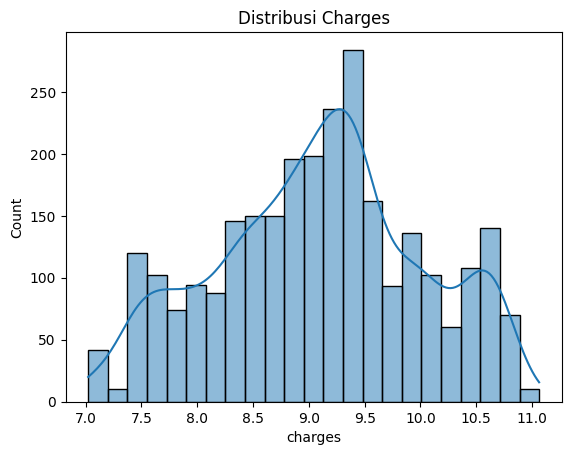

In [6]:
# Distribusi target
sns.histplot(y, kde=True)
plt.title("Distribusi Charges")
plt.show()


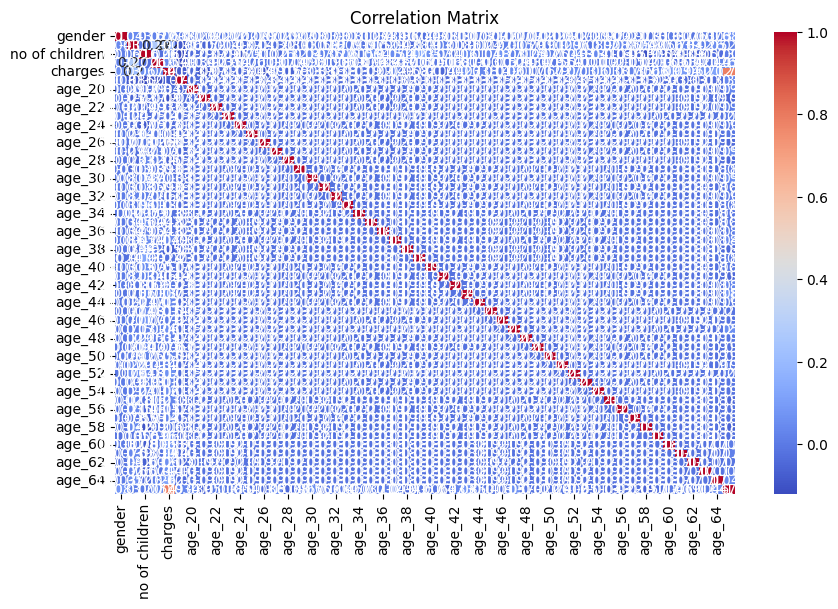

In [7]:
# Korelasi
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [8]:
def evaluate(nama, y_test, y_pred, test_size):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{nama}")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    return [nama, test_size, mae, mse, rmse, r2]

In [9]:
splits = [0.3, 0.2, 0.1]

for test_size in splits:
    print(f"\n=== Split {int((1-test_size)*100)}:{int(test_size*100)} ===")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # =====================
    # 1. XGBOOST
    # =====================
    xgb = XGBRegressor(
        n_estimators=3500,
        learning_rate=0.005,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    )
    xgb.fit(X_train, y_train)
    y_pred_xgb = xgb.predict(X_test)

    # =====================
    # 2. EXTRA TREES
    # =====================
    et = ExtraTreesRegressor(
        n_estimators=1500,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=1.0,
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    )
    et.fit(X_train, y_train)
    y_pred_et = et.predict(X_test)

    # =====================
    # 3. HIST GRADIENT BOOSTING
    # =====================
    hgb = HistGradientBoostingRegressor(
        max_iter=1000,
        learning_rate=0.03,
        max_depth=10,
        random_state=42
    )
    hgb.fit(X_train, y_train)
    y_pred_hgb = hgb.predict(X_test)

    # =====================
    # JIKA PAKAI LOG1P (OPSIONAL)
    # =====================
    # HAPUS BAGIAN INI kalau kamu TIDAK pakai log1p sebelumnya
    y_test_real = np.expm1(y_test)
    y_pred_xgb = np.expm1(y_pred_xgb)
    y_pred_et = np.expm1(y_pred_et)
    y_pred_hgb = np.expm1(y_pred_hgb)

    # =====================
    # EVALUASI
    # =====================
    def evaluate(nama, y_true, y_pred):
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)

        print(f"\n{nama}")
        print(f"MAE  : {mae:.4f}")
        print(f"MSE  : {mse:.4f}")
        print(f"RMSE : {rmse:.4f}")
        print(f"R2   : {r2:.4f}")

    evaluate("XGBoost", y_test_real, y_pred_xgb)
    evaluate("ExtraTrees", y_test_real, y_pred_et)
    evaluate("HistGradientBoosting", y_test_real, y_pred_hgb)


=== Split 70:30 ===

XGBoost
MAE  : 2554.9627
MSE  : 21860477.2743
RMSE : 4675.5189
R2   : 0.8545

ExtraTrees
MAE  : 1693.7754
MSE  : 14064920.7016
RMSE : 3750.3227
R2   : 0.9064

HistGradientBoosting
MAE  : 2583.1563
MSE  : 21461908.5698
RMSE : 4632.6999
R2   : 0.8572

=== Split 80:20 ===

XGBoost
MAE  : 2561.7615
MSE  : 22413495.6921
RMSE : 4734.2894
R2   : 0.8626

ExtraTrees
MAE  : 1496.5393
MSE  : 12119170.7077
RMSE : 3481.2599
R2   : 0.9257

HistGradientBoosting
MAE  : 2587.7938
MSE  : 22194940.9892
RMSE : 4711.1507
R2   : 0.8640

=== Split 90:10 ===

XGBoost
MAE  : 2623.3357
MSE  : 22717047.1652
RMSE : 4766.2404
R2   : 0.8588

ExtraTrees
MAE  : 1165.8545
MSE  : 6342630.2294
RMSE : 2518.4579
R2   : 0.9606

HistGradientBoosting
MAE  : 2370.3532
MSE  : 18450927.8665
RMSE : 4295.4543
R2   : 0.8853
